# Trying different class2 classification methods

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys

from pathlib import Path



# Own functions
# Necessary to import from src dir
sys.path.append("../..")
import src.preprocessing_minimal as ppm

## Reading in the data

In [71]:
data_dir = Path('../data')
output_dir = Path('../outputs')

train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
#final_test_df = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date"])

In [72]:
X_train, y_train2, y_train4 = ppm.split_xy(train_df)

## Scaling the data

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

## Logistic regression

In [74]:
#Fitting logistic regression to class2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


avg_accuracies = []
avg_perplexities = []

for c in np.linspace(0.1, 1.0, 50):
    accuracies = []
    perplexities = []
    log_model = LogisticRegression(C=c, l1_ratio=1, solver='liblinear')
    for train_index, test_index in skf.split(X_train_scaled, y_train2):
        X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
        y_train_fold, y_test_fold = y_train2.iloc[train_index], y_train2.iloc[test_index]
        log_model.fit(X_train_fold, y_train_fold)
        
        y_pred_fold = log_model.predict(X_test_fold)
        y_pred_prob_fold = log_model.predict_proba(X_test_fold)[:, 1]

        binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
        perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
        accuracies.append(binary_accuracy)
        perplexities.append(perplexity)
    avg_accuracies.append(np.mean(accuracies))
    avg_perplexities.append(np.mean(perplexities))

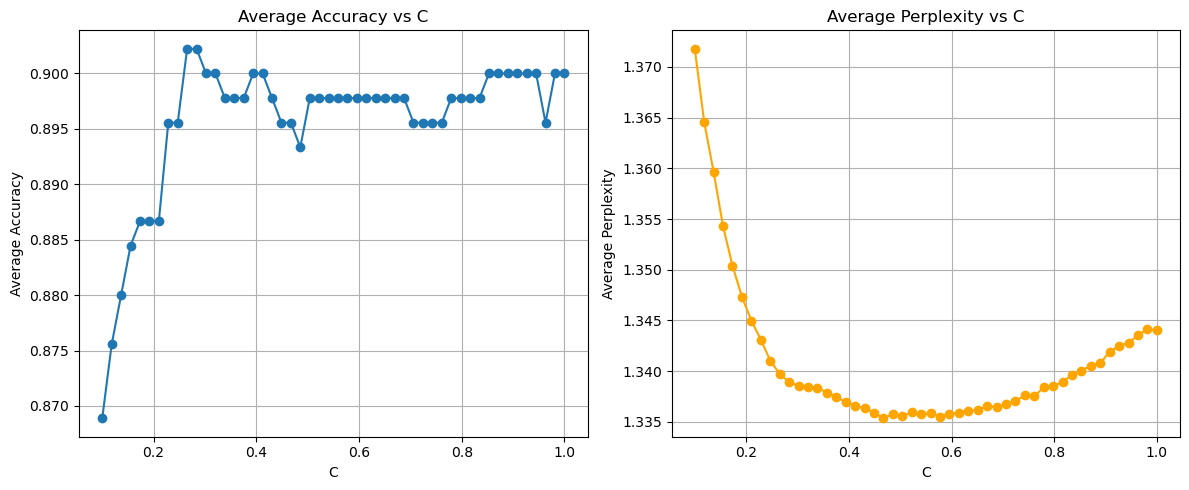

In [75]:
#plotting the accuracy and perplexity against C
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0.1, 1.0, 50), avg_accuracies, marker='o')
plt.title('Average Accuracy vs C')
plt.xlabel('C')
plt.ylabel('Average Accuracy')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(np.linspace(0.1, 1.0, 50), avg_perplexities, marker='o', color='orange')
plt.title('Average Perplexity vs C')
plt.xlabel('C')
plt.ylabel('Average Perplexity')
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# Trainig the best model on the whole training set
best_c_index = np.argmax(avg_accuracies)
best_c = np.linspace(0.1, 1.0, 50)[best_c_index]
print(f"Best C: {best_c:.4f} with Average Accuracy: {avg_accuracies[best_c_index]:.4f} and Average Perplexity: {avg_perplexities[best_c_index]:.4f}")


Best C: 0.2653 with Average Accuracy: 0.9022 and Average Perplexity: 1.3397


If accuracy and perplexity peak at different C, we can tune two different models.